# Etapa 2 — MLP PyTorch + Comparação de Modelos

Treinamento da rede neural MLP com PyTorch, comparação com todos os baselines e análise de custo (FP vs FN).

## 0. Setup

In [9]:
import logging
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

from customer_churn_ibm.config import MLFLOW_EXPERIMENT, SEED
from customer_churn_ibm.data import build_preprocessor, clean_data, get_splits, load_raw_data
from customer_churn_ibm.model_baseline import BASELINE_CONFIGS
from customer_churn_ibm.model_mlp import ChurnMLP, MLPClassifier

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA disponível: {torch.cuda.is_available()}')

PyTorch version: 2.12.0
CUDA disponível: False


## 1. Dados

In [10]:
df = clean_data(load_raw_data())
X_train, X_test, y_train, y_test = get_splits(df)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

INFO:customer_churn_ibm.data:Baixando dataset via kagglehub
INFO:customer_churn_ibm.data:Dataset carregado: 7043 linhas, 33 colunas
INFO:customer_churn_ibm.data:Dados limpos: 7043 linhas, 20 colunas


Train: (5634, 19) | Test: (1409, 19)


## 2. Arquitetura do MLP

In [11]:
# Inspecionar dimensão de entrada após o pipeline de pré-processamento
preprocessor = build_preprocessor()
X_sample = preprocessor.fit_transform(X_train)
input_dim = X_sample.shape[1]
print(f'Dimensão de entrada após pré-processamento: {input_dim}')

model_preview = ChurnMLP(input_dim=input_dim)
print(model_preview)

Dimensão de entrada após pré-processamento: 46
ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=46, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 3. Treinamento do MLP com Early Stopping

In [12]:
mlflow.set_experiment(MLFLOW_EXPERIMENT)

mlp_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('model', MLPClassifier(
        hidden_dims=(128, 64, 32),
        dropout=0.3,
        lr=1e-3,
        epochs=100,
        patience=15,
        batch_size=32,
    )),
])

with mlflow.start_run(run_name='MLP_PyTorch_notebook'):
    mlp_pipeline.fit(X_train, y_train)

    y_pred_mlp = mlp_pipeline.predict(X_test)
    y_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

    mlp_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_mlp),
        'precision': precision_score(y_test, y_pred_mlp, zero_division=0),
        'recall': recall_score(y_test, y_pred_mlp, zero_division=0),
        'f1': f1_score(y_test, y_pred_mlp, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba_mlp),
        'pr_auc': average_precision_score(y_test, y_proba_mlp),
    }

    mlflow.log_params({
        'model': 'MLP_PyTorch',
        'hidden_dims': '(128, 64, 32)',
        'dropout': 0.3,
        'lr': 1e-3,
        'seed': SEED,
    })
    mlflow.log_metrics(mlp_metrics)

print('Métricas MLP:')
for k, v in mlp_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

INFO:customer_churn_ibm.model_mlp:Early stopping no epoch 28 — val_loss=0.7284
INFO:customer_churn_ibm.model_mlp:Treinamento concluído. Best val_loss=0.7284


Métricas MLP:
  accuracy    : 0.7452
  precision   : 0.5133
  recall      : 0.7727
  f1          : 0.6169
  roc_auc     : 0.8428
  pr_auc      : 0.6321


## 4. Curvas ROC e Precision-Recall

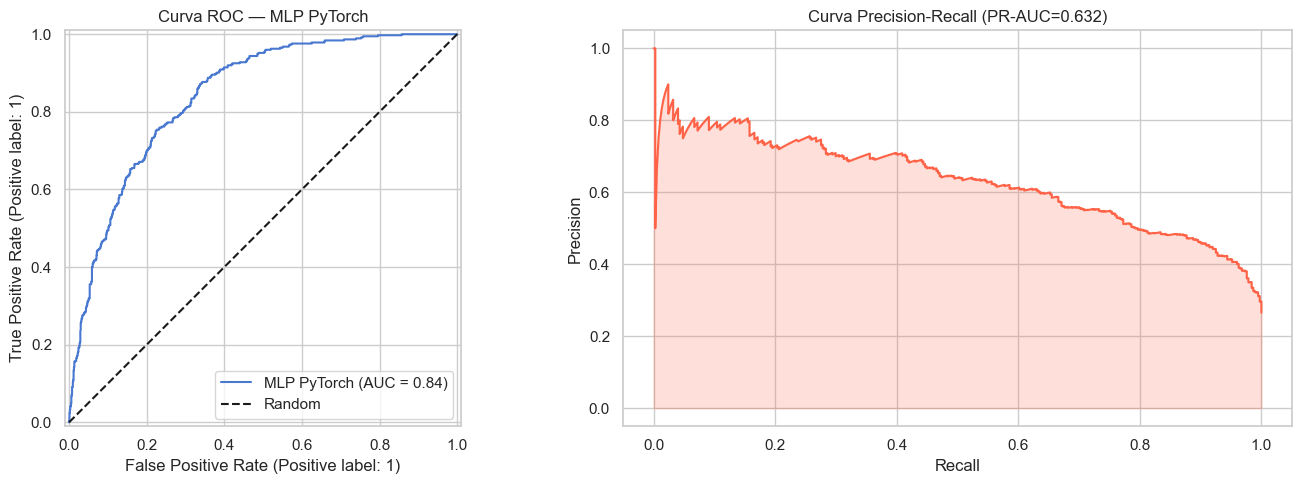

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba_mlp, name='MLP PyTorch', ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title('Curva ROC — MLP PyTorch')
axes[0].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba_mlp)
axes[1].plot(rec, prec, color='tomato')
axes[1].fill_between(rec, prec, alpha=0.2, color='tomato')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Curva Precision-Recall (PR-AUC={mlp_metrics["pr_auc"]:.3f})')

plt.tight_layout()
plt.show()

## 5. Matriz de Confusão

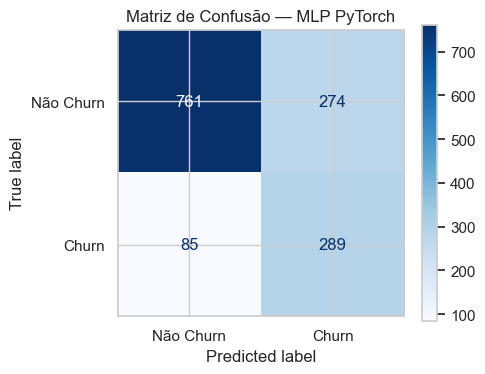

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp, display_labels=['Não Churn', 'Churn'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão — MLP PyTorch')
plt.tight_layout()
plt.show()

## 6. Comparação: MLP vs Todos os Baselines

In [15]:
all_results = [{'model': 'MLP_PyTorch', **mlp_metrics}]

for name, cfg in BASELINE_CONFIGS.items():
    pipeline = Pipeline([('preprocessor', build_preprocessor()), ('model', cfg['model'])])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(cfg['model'], 'predict_proba') else None
    row = {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else None,
        'pr_auc': average_precision_score(y_test, y_proba) if y_proba is not None else None,
    }
    all_results.append(row)

comparison = pd.DataFrame(all_results).sort_values('f1', ascending=False).reset_index(drop=True)
comparison.style.highlight_max(subset=['f1', 'roc_auc', 'pr_auc', 'recall'], color='lightgreen')

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,MLP_PyTorch,0.745209,0.513321,0.772727,0.616862,0.842827,0.632077
1,RandomForest,0.804116,0.650307,0.566845,0.605714,0.844920,0.660075
2,LogisticRegression,0.801987,0.643505,0.569519,0.604255,0.848867,0.645252
3,GradientBoosting,0.799858,0.649351,0.534759,0.586510,0.852251,0.672427
4,DummyClassifier,0.734564,0.000000,0.000000,0.000000,0.500000,0.265436


## 7. Análise de Custo: FP vs FN

No contexto de churn:
- **FN (Falso Negativo):** cliente que vai sair mas não foi identificado → perda do cliente (custo alto)
- **FP (Falso Positivo):** cliente que ficaria mas recebe ação de retenção desnecessária → custo de campanha (baixo)

Geralmente, `custo_FN >> custo_FP` → preferimos maximizar recall.

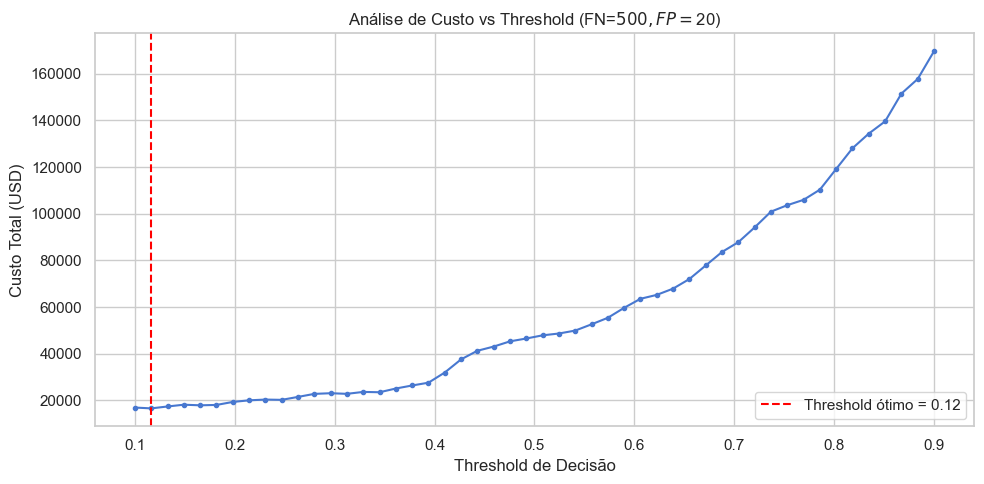

Threshold padrão (0.5): custo = $46,540
Threshold ótimo (0.12): custo = $16,580


In [16]:
# Parâmetros de custo
CUSTO_FN = 500   # receita mensal perdida ao não reter o cliente
CUSTO_FP = 20    # custo da campanha de retenção desnecessária

thresholds = np.linspace(0.1, 0.9, 50)
costs = []

for thr in thresholds:
    y_pred_thr = (y_proba_mlp >= thr).astype(int)
    fp = ((y_pred_thr == 1) & (np.array(y_test) == 0)).sum()
    fn = ((y_pred_thr == 0) & (np.array(y_test) == 1)).sum()
    total_cost = fp * CUSTO_FP + fn * CUSTO_FN
    costs.append({'threshold': thr, 'cost': total_cost, 'fp': fp, 'fn': fn})

cost_df = pd.DataFrame(costs)
best_thr = cost_df.loc[cost_df['cost'].idxmin(), 'threshold']

plt.figure(figsize=(10, 5))
plt.plot(cost_df['threshold'], cost_df['cost'], 'b-o', markersize=3)
plt.axvline(best_thr, color='red', linestyle='--', label=f'Threshold ótimo = {best_thr:.2f}') # type: ignore
plt.xlabel('Threshold de Decisão')
plt.ylabel('Custo Total (USD)')
plt.title(f'Análise de Custo vs Threshold (FN=${CUSTO_FN}, FP=${CUSTO_FP})')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Threshold padrão (0.5): custo = ${cost_df.loc[cost_df.threshold.sub(0.5).abs().idxmin(), "cost"]:,.0f}')
print(f'Threshold ótimo ({best_thr:.2f}): custo = ${cost_df["cost"].min():,.0f}')